# v15 — Deflated Sharpe Ratio: apakah v13 "menang" karena beneran bagus, atau karena kebetulan?

**Masalah yang diselesaikan:** dari v02 sampai v13, ada **10 versi strategi** yang dicoba
(v02, v03, v04, v05, v06, v07, v10, v11, v12, v13 — v01/v08/v09 dikecualikan krn bukan versi
strategi trading baru: v01 cuma EDA, v08 investigasi pola, v09 validasi kill-switch, ketiganya
tidak menghasilkan trade log dgn sinyal berbeda). Tiap kali kita pilih versi "terbaik" dari
backtest, itu sebetulnya **cherry-picking** dari 10 percobaan — makin banyak percobaan, makin
besar kemungkinan salah satu kelihatan bagus murni karena kebetulan cocok dgn data historis,
bukan karena beneran lebih superior secara sistematis.

**Analoginya:** kalau 1000 orang lempar koin 10x, pasti ada yang dapat 9-10 kepala beruntun —
bukan krn jago, tapi krn dari 1000 percobaan pasti ada yang beruntung. Sharpe Ratio biasa
(return relatif ke volatilitas) TIDAK tahu berapa kali kita sudah mencoba sebelum dapat angka
itu — jadi bisa menipu kalau dipakai apa adanya setelah banyak iterasi.

**Deflated Sharpe Ratio (DSR)**, dari Marcos López de Prado (*Advances in Financial Machine
Learning*), mengoreksi Sharpe Ratio untuk 3 hal:
1. **Berapa banyak strategi/versi yang dicoba** (N=10 di sini) — makin banyak, makin didiskon.
2. **Panjang data** (jumlah observasi return) — makin pendek, makin gak reliable.
3. **Bentuk distribusi return** (skewness/kurtosis) — return yang "aneh" (fat-tail, skewed)
   butuh sample lebih besar utk Sharpe-nya bisa dipercaya.

**Cara baca hasilnya:** DSR berupa probabilitas (0-1) — "setelah memperhitungkan bahwa kita
sudah mencoba N versi, seberapa yakin Sharpe versi terbaik itu BENERAN nyata (bukan luck)?"
DSR=0.85 berarti 85% yakin nyata. **Di bawah 0.5 = warning, kemenangan v13 mungkin sebagian
besar keberuntungan, bukan skill.**

**Bukan riset ubah parameter/strategi** — v15 TIDAK mengubah sinyal, TP/SL, atau apa pun dari
v13. Ini murni **audit statistik** atas proses seleksi versi yang sudah dilakukan v02-v13,
menjawab "seberapa yakin kita v13 itu beneran lebih baik, bukan cuma menang undian." Isu kedua
dari 3 yang direncanakan untuk pematangan v13 (setelah Monte Carlo di v14).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

STRATEGY_NAME = "m5_scalping"
VERSION = "v15"

PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed" / STRATEGY_NAME
EXPORT_DIR = PROJECT_ROOT / "dataset" / "exports" / STRATEGY_NAME / VERSION
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (14, 5)

## 1. Load 10 trade log (v02-v13) & potong ke rentang waktu SAMA (apple-to-apple)

**Masalah yang ditemukan saat eksplorasi data:** trade log yang tersimpan tiap versi punya
rentang tanggal beda-beda — v02/v03/v04/v05/v06/v07 punya data FULL period (2025-01 s/d
2026-08), sedangkan v10/v11/v12/v13 cuma TEST period (2026-03 s/d 2026-08, krn versi2 itu
memang dirancang & divalidasi khusus out-of-sample). Kalau dibandingkan apa adanya, versi yang
lebih baru "diuntungkan/dirugikan" tergantung rezim harga di rentang waktunya masing-masing --
BUKAN perbandingan yang adil.

**Solusi:** semua 10 trade log dipotong ke **TEST period yang sama** (2026-03-01 s/d 2026-08-06)
sebelum dihitung Sharpe-nya -- supaya perbedaan Sharpe murni mencerminkan perbedaan KUALITAS
SINYAL versi tsb, bukan perbedaan rezim harga yang kebetulan dilewati.

In [2]:
TEST_START = pd.Timestamp("2026-03-01", tz="UTC")
TEST_END = pd.Timestamp("2026-08-06", tz="UTC")

VERSION_FILES = {
    "v02": PROCESSED_DIR / "v02" / "trade_log_full.csv",
    "v03": PROCESSED_DIR / "v03" / "trade_log_full.csv",
    "v04": PROCESSED_DIR / "v04" / "trade_log_full.csv",
    "v05": PROCESSED_DIR / "v05" / "trade_log_full.csv",
    "v06": PROCESSED_DIR / "v06" / "trade_log_full.csv",
    "v07": PROCESSED_DIR / "v07" / "trade_log_full.csv",
    "v10": PROCESSED_DIR / "v10" / "trade_log_test_v10.csv",
    "v11": PROCESSED_DIR / "v11" / "trade_log_test_v11.csv",
    "v12": PROCESSED_DIR / "v12" / "trade_log_test_v12_th9.csv",
    "v13": PROCESSED_DIR / "v13" / "trade_log_test_small_profit.csv",
}

VERSION_LABELS = {
    "v02": "v02 baseline (score>=6, no H1 filter)",
    "v03": "v03 (score>=11, H1 filter)",
    "v04": "v04 (TP=12pt/SL=6pt fixed)",
    "v05": "v05 (ML Random Forest, ditolak)",
    "v06": "v06 (TP/SL ATR-relatif)",
    "v07": "v07 (breakout entry, ditolak)",
    "v10": "v10-SKIP (Order Block filter)",
    "v11": "v11 (trailing stop, ditolak)",
    "v12": "v12 (de-redundant scoring)",
    "v13": "v13 (v12+OB+exhaustion, LIVE)",
}

trade_logs = {}
for v, path in VERSION_FILES.items():
    df = pd.read_csv(path)
    df["entry_time"] = pd.to_datetime(df["entry_time"])
    df_test_period = df[(df["entry_time"] >= TEST_START) & (df["entry_time"] < TEST_END)].copy()
    trade_logs[v] = df_test_period.sort_values("entry_time").reset_index(drop=True)
    print(f"{v:5s} {VERSION_LABELS[v]:45s} n={len(df_test_period):4d} trade di TEST period")

v02   v02 baseline (score>=6, no H1 filter)         n=2563 trade di TEST period
v03   v03 (score>=11, H1 filter)                    n= 187 trade di TEST period
v04   v04 (TP=12pt/SL=6pt fixed)                    n= 652 trade di TEST period
v05   v05 (ML Random Forest, ditolak)               n=1047 trade di TEST period
v06   v06 (TP/SL ATR-relatif)                       n= 489 trade di TEST period
v07   v07 (breakout entry, ditolak)                 n= 372 trade di TEST period
v10   v10-SKIP (Order Block filter)                 n= 594 trade di TEST period
v11   v11 (trailing stop, ditolak)                  n= 318 trade di TEST period
v12   v12 (de-redundant scoring)                    n= 192 trade di TEST period
v13   v13 (v12+OB+exhaustion, LIVE)                 n= 196 trade di TEST period


## 2. Konversi PnL trade jadi return HARIAN (bukan per-trade)

Sharpe Ratio konvensional dihitung dari return per PERIODE WAKTU TETAP (harian/mingguan/bulanan),
bukan per event yang frekuensinya berubah-ubah (per trade) -- krn asumsi statistiknya (independent
& identically distributed) lebih masuk akal utk unit waktu tetap. Return dihitung sbg
`net_pnl_hari_itu / INITIAL_EQUITY` (basis $100, konsisten dgn v14) -- hari tanpa trade dapat
return 0% (bukan di-skip), supaya deret waktunya tetap representatif periode kalender penuh,
bukan cuma hari-hari yang kebetulan ada trade.

In [3]:
INITIAL_EQUITY = 100.0

# Kalender harian lengkap TEST period (termasuk weekend -- pasar forex tutup Sabtu penuh &
# sebagian Minggu, tapi tetap dimasukkan sbg hari return=0% biar deret waktu tiap versi
# punya panjang N yang SAMA PERSIS -- penting utk perbandingan Sharpe yang adil).
full_calendar = pd.date_range(TEST_START, TEST_END - pd.Timedelta(days=1), freq="D", tz="UTC")

daily_returns = {}
for v, df in trade_logs.items():
    daily_pnl = df.groupby(df["entry_time"].dt.date)["pnl"].sum()
    daily_pnl.index = pd.to_datetime(daily_pnl.index, utc=True)
    daily_pnl = daily_pnl.reindex(full_calendar, fill_value=0.0)
    daily_returns[v] = daily_pnl / INITIAL_EQUITY

returns_df = pd.DataFrame(daily_returns)
print(f"Deret return harian: {len(full_calendar)} hari kalender ({TEST_START.date()} s/d {(TEST_END - pd.Timedelta(days=1)).date()})")
print(f"Semua versi punya panjang N yang sama: {(returns_df.count() == len(full_calendar)).all()}")
returns_df.describe().T[["count", "mean", "std", "min", "max"]]

Deret return harian: 158 hari kalender (2026-03-01 s/d 2026-08-05)
Semua versi punya panjang N yang sama: True


,count,mean,std,min,max
v02,158.0,-0.011275,0.347340,-1.800000,0.960000
v03,158.0,0.015699,0.107144,-0.240000,0.540000
v04,158.0,0.057839,0.258083,-0.660000,1.933000
v05,158.0,0.242493,0.258318,-0.153203,1.477388
v06,158.0,0.076504,0.346610,-0.737862,1.848295
v07,158.0,0.036046,0.257750,-0.682862,1.076772
v10,158.0,0.106317,0.350821,-0.614348,1.668413
v11,158.0,0.082110,0.235781,-0.687323,1.131004
v12,158.0,0.075512,0.212215,-0.374432,1.344125
v13,158.0,0.074609,0.188930,-0.374432,1.166803


## 3. Implementasi Sharpe Ratio, Probabilistic Sharpe Ratio (PSR), dan Deflated Sharpe Ratio (DSR)

Mengikuti formula standar López de Prado (*Advances in Financial Machine Learning*, 2018, Ch.
14) & Bailey-López de Prado (2014) "The Deflated Sharpe Ratio":

- **Sharpe Ratio (SR)**: `mean(returns) / std(returns)`, non-annualized (harian) di sini --
  krn kita cuma bandingkan RELATIF antar versi pada rentang waktu yang sama, annualisasi tidak
  perlu (faktor skala konstan, tidak mengubah ranking).
- **PSR (Probabilistic Sharpe Ratio)**: probabilitas SR asli > SR benchmark (di sini benchmark
  = 0, "lebih baik dari tidak trading sama sekali"), dikoreksi utk panjang sample (N) &
  non-normalitas return (skewness *gamma3*, kurtosis *gamma4*). Rumus:
  `PSR = CDF( (SR - SR_benchmark) * sqrt(N-1) / sqrt(1 - gamma3*SR + (gamma4-1)/4*SR^2) )`
- **DSR (Deflated Sharpe Ratio)**: PSR yang benchmark-nya BUKAN 0, tapi **SR maksimum yang
  DIHARAPKAN muncul murni krn kebetulan** dari N percobaan independen (variance across trials
  + expected max of N Gaussian draws) -- ini yang mengoreksi utk "berapa banyak versi yang
  sudah dicoba". Rumus expected max SR dari N trial (Bailey & López de Prado 2014, eq. 7):
  `E[max(SR)] = sqrt(V[SR]) * ( (1-gamma_euler)*Z^-1(1-1/N) + gamma_euler*Z^-1(1-1/(N*e)) )`
  dgn *gamma_euler* = konstanta Euler-Mascheroni (~0.5772), *Z^-1* = inverse CDF normal.

In [4]:
EULER_MASCHERONI = 0.5772156649


def sharpe_ratio(returns: np.ndarray) -> float:
    std = returns.std(ddof=1)
    if std == 0:
        return 0.0
    return float(returns.mean() / std)


def probabilistic_sharpe_ratio(returns: np.ndarray, sr_benchmark: float = 0.0) -> float:
    """PSR: probabilitas SR asli > sr_benchmark, dikoreksi panjang sample & non-normalitas."""
    n = len(returns)
    sr = sharpe_ratio(returns)
    skew = stats.skew(returns)
    kurt = stats.kurtosis(returns, fisher=False)  # fisher=False -> kurtosis normal = 3 (bukan 0)

    numerator = (sr - sr_benchmark) * np.sqrt(n - 1)
    denominator = np.sqrt(max(1 - skew * sr + (kurt - 1) / 4 * sr**2, 1e-12))
    z = numerator / denominator
    return float(stats.norm.cdf(z))


def expected_max_sharpe(sr_across_trials: np.ndarray, n_effective: int) -> float:
    """E[max(SR)] dari N percobaan independen -- benchmark utk DSR (Bailey & Lopez de Prado 2014).
    sr_across_trials: array Sharpe Ratio SEMUA versi yang dicoba (dipakai hitung variance antar-trial).
    n_effective: jumlah percobaan independen (N)."""
    var_sr = sr_across_trials.var(ddof=1)
    if var_sr <= 0 or n_effective <= 1:
        return 0.0
    z_a = stats.norm.ppf(1 - 1.0 / n_effective)
    z_b = stats.norm.ppf(1 - 1.0 / (n_effective * np.e))
    return float(np.sqrt(var_sr) * ((1 - EULER_MASCHERONI) * z_a + EULER_MASCHERONI * z_b))


def deflated_sharpe_ratio(returns: np.ndarray, sr_across_trials: np.ndarray, n_effective: int) -> tuple[float, float]:
    """Return (DSR, sr_benchmark_used) -- DSR = PSR dgn benchmark = expected max SR dari N trial."""
    sr_benchmark = expected_max_sharpe(sr_across_trials, n_effective)
    dsr = probabilistic_sharpe_ratio(returns, sr_benchmark=sr_benchmark)
    return dsr, sr_benchmark

## 4. Hitung Sharpe Ratio semua 10 versi (return harian, TEST period yang sama)

In [5]:
sharpe_by_version = {}
for v in VERSION_FILES:
    r = returns_df[v].to_numpy()
    sr = sharpe_ratio(r)
    psr = probabilistic_sharpe_ratio(r, sr_benchmark=0.0)
    sharpe_by_version[v] = {
        "label": VERSION_LABELS[v],
        "sharpe_ratio": round(sr, 4),
        "psr_vs_zero": round(psr, 4),
        "skewness": round(float(stats.skew(r)), 3),
        "kurtosis": round(float(stats.kurtosis(r, fisher=False)), 3),
        "n_trades": len(trade_logs[v]),
        "n_days": len(r),
    }

sharpe_table = pd.DataFrame(sharpe_by_version).T
sharpe_table = sharpe_table.sort_values("sharpe_ratio", ascending=False)
print("=== Sharpe Ratio (harian) semua versi, diurutkan tertinggi -> terendah ===")
sharpe_table

=== Sharpe Ratio (harian) semua versi, diurutkan tertinggi -> terendah ===


,label,sharpe_ratio,psr_vs_zero,skewness,kurtosis,n_trades,n_days
v05,"v05 (ML Random Forest, ditolak)",0.9387,1.0,1.746,7.919,1047,158
v13,"v13 (v12+OB+exhaustion, LIVE)",0.3949,1.0,3.167,16.486,196,158
v12,v12 (de-redundant scoring),0.3558,1.0,3.322,17.609,192,158
v11,"v11 (trailing stop, ditolak)",0.3482,1.0,1.718,8.169,318,158
v10,v10-SKIP (Order Block filter),0.3031,1.0,1.511,6.356,594,158
v04,v04 (TP=12pt/SL=6pt fixed),0.2241,0.9998,2.842,20.167,652,158
v06,v06 (TP/SL ATR-relatif),0.2207,0.9992,1.451,7.783,489,158
v03,"v03 (score>=11, H1 filter)",0.1465,0.9815,1.827,8.765,187,158
v07,"v07 (breakout entry, ditolak)",0.1398,0.9723,1.366,6.681,372,158
v02,"v02 baseline (score>=6, no H1 filter)",-0.0325,0.3405,-0.679,7.128,2563,158


## 5. Deflated Sharpe Ratio — apakah versi terbaik beneran nyata?

`N_TRIALS = 10` — jumlah versi strategi yang benar-benar dicoba (v02-v13, exclude v01/v08/v09
yang bukan versi strategi baru). Dihitung utk versi dgn Sharpe TERTINGGI (apa pun versinya --
tidak diasumsikan v13, biar hasilnya jujur dari data, bukan dari ekspektasi).

In [6]:
N_TRIALS = 10

all_sr = sharpe_table["sharpe_ratio"].to_numpy().astype(float)
best_version = str(sharpe_table.index[0])
best_sr = sharpe_table.loc[best_version, "sharpe_ratio"]

sr_benchmark = expected_max_sharpe(all_sr, N_TRIALS)
print(f"Versi dgn Sharpe tertinggi: {best_version} ({VERSION_LABELS[best_version]})")
print(f"Sharpe Ratio {best_version}: {best_sr:.4f}")
print(f"\nE[max(SR)] dari {N_TRIALS} percobaan murni kebetulan (benchmark DSR): {sr_benchmark:.4f}")
print(f"(artinya: kalau kita coba {N_TRIALS} strategi RANDOM/tidak punya edge, Sharpe TERTINGGI")
print(f" di antara mereka diharapkan sekitar {sr_benchmark:.4f} murni krn variasi statistik)")

r_best = returns_df[best_version].to_numpy()
dsr, _ = deflated_sharpe_ratio(r_best, all_sr, N_TRIALS)
psr_vs_zero = probabilistic_sharpe_ratio(r_best, sr_benchmark=0.0)

print(f"\n=== Hasil DSR untuk {best_version} ===")
print(f"  PSR vs 0 (lebih baik dari tidak trading): {psr_vs_zero:.4f} ({psr_vs_zero*100:.1f}%)")
print(f"  DSR (dikoreksi utk {N_TRIALS} percobaan): {dsr:.4f} ({dsr*100:.1f}%)")
print(f"\n  Selisih PSR - DSR = {psr_vs_zero - dsr:.4f} -- ini besarnya 'diskon' akibat multiple testing")

Versi dgn Sharpe tertinggi: v05 (v05 (ML Random Forest, ditolak))
Sharpe Ratio v05: 0.9387

E[max(SR)] dari 10 percobaan murni kebetulan (benchmark DSR): 0.4045
(artinya: kalau kita coba 10 strategi RANDOM/tidak punya edge, Sharpe TERTINGGI
 di antara mereka diharapkan sekitar 0.4045 murni krn variasi statistik)

=== Hasil DSR untuk v05 ===
  PSR vs 0 (lebih baik dari tidak trading): 1.0000 (100.0%)
  DSR (dikoreksi utk 10 percobaan): 1.0000 (100.0%)

  Selisih PSR - DSR = 0.0000 -- ini besarnya 'diskon' akibat multiple testing


## 6. DSR untuk SEMUA versi (bukan cuma yang tertinggi) — gambaran lengkap

In [7]:
dsr_rows = []
for v in VERSION_FILES:
    r = returns_df[v].to_numpy()
    sr = sharpe_ratio(r)
    dsr, _ = deflated_sharpe_ratio(r, all_sr, N_TRIALS)
    dsr_rows.append({
        "version": v,
        "label": VERSION_LABELS[v],
        "sharpe_ratio": round(sr, 4),
        "dsr": round(dsr, 4),
        "verdict": "SIGNIFIKAN (DSR>=0.5)" if dsr >= 0.5 else "TIDAK signifikan (DSR<0.5)",
    })

dsr_table = pd.DataFrame(dsr_rows).sort_values("sharpe_ratio", ascending=False).set_index("version")
print(f"=== DSR semua versi (benchmark = E[max(SR)] dari {N_TRIALS} percobaan = {sr_benchmark:.4f}) ===")
dsr_table

=== DSR semua versi (benchmark = E[max(SR)] dari 10 percobaan = 0.4045) ===


,label,sharpe_ratio,dsr,verdict
version,,,,
v05,"v05 (ML Random Forest, ditolak)",0.9387,1.0000,SIGNIFIKAN (DSR>=0.5)
v13,"v13 (v12+OB+exhaustion, LIVE)",0.3949,0.4195,TIDAK signifikan (DSR<0.5)
v12,v12 (de-redundant scoring),0.3558,0.1489,TIDAK signifikan (DSR<0.5)
v11,"v11 (trailing stop, ditolak)",0.3482,0.1850,TIDAK signifikan (DSR<0.5)
v10,v10-SKIP (Order Block filter),0.3031,0.0595,TIDAK signifikan (DSR<0.5)
v04,v04 (TP=12pt/SL=6pt fixed),0.2241,0.0018,TIDAK signifikan (DSR<0.5)
v06,v06 (TP/SL ATR-relatif),0.2207,0.0042,TIDAK signifikan (DSR<0.5)
v03,"v03 (score>=11, H1 filter)",0.1465,0.0001,TIDAK signifikan (DSR<0.5)
v07,"v07 (breakout entry, ditolak)",0.1398,0.0001,TIDAK signifikan (DSR<0.5)


## 7. Sensitivity check — bagaimana DSR berubah kalau N_TRIALS diasumsikan beda?

`N_TRIALS=10` itu hitungan versi STRATEGI utama, tapi kalau dihitung lebih longgar (termasuk
semua eksperimen/grid search parameter dalam tiap versi), jumlah percobaan sesungguhnya bisa
JAUH lebih besar (mis. grid search v04 nyoba 32 kombinasi, v12 nyoba banyak threshold). Sel ini
menguji seberapa sensitif kesimpulan DSR terhadap asumsi N -- kalau DSR versi terbaik masih
di atas 0.5 bahkan dgn N besar, itu sinyal lebih meyakinkan drpd DSR yang cuma solid di N=10.

In [8]:
N_TRIALS_CANDIDATES = [5, 10, 15, 20, 30, 50, 100]

sensitivity_rows = []
for n in N_TRIALS_CANDIDATES:
    sr_bench_n = expected_max_sharpe(all_sr, n)
    dsr_n = probabilistic_sharpe_ratio(r_best, sr_benchmark=sr_bench_n)
    sensitivity_rows.append({
        "n_trials_assumed": n,
        "sr_benchmark": round(sr_bench_n, 4),
        f"dsr_{best_version}": round(dsr_n, 4),
        "verdict": "SIGNIFIKAN" if dsr_n >= 0.5 else "TIDAK signifikan",
    })

sensitivity_table = pd.DataFrame(sensitivity_rows).set_index("n_trials_assumed")
print(f"=== Sensitivity DSR {best_version} terhadap asumsi N_TRIALS ===")
sensitivity_table

=== Sensitivity DSR v05 terhadap asumsi N_TRIALS ===


,sr_benchmark,dsr_v05,verdict
n_trials_assumed,,,
5,0.3064,1.0000,SIGNIFIKAN
10,0.4045,1.0000,SIGNIFIKAN
15,0.4549,1.0000,SIGNIFIKAN
20,0.4883,1.0000,SIGNIFIKAN
30,0.5327,1.0000,SIGNIFIKAN
50,0.5848,1.0000,SIGNIFIKAN
100,0.6502,0.9999,SIGNIFIKAN


## 8. Visualisasi — Sharpe Ratio tiap versi vs benchmark "kebetulan"

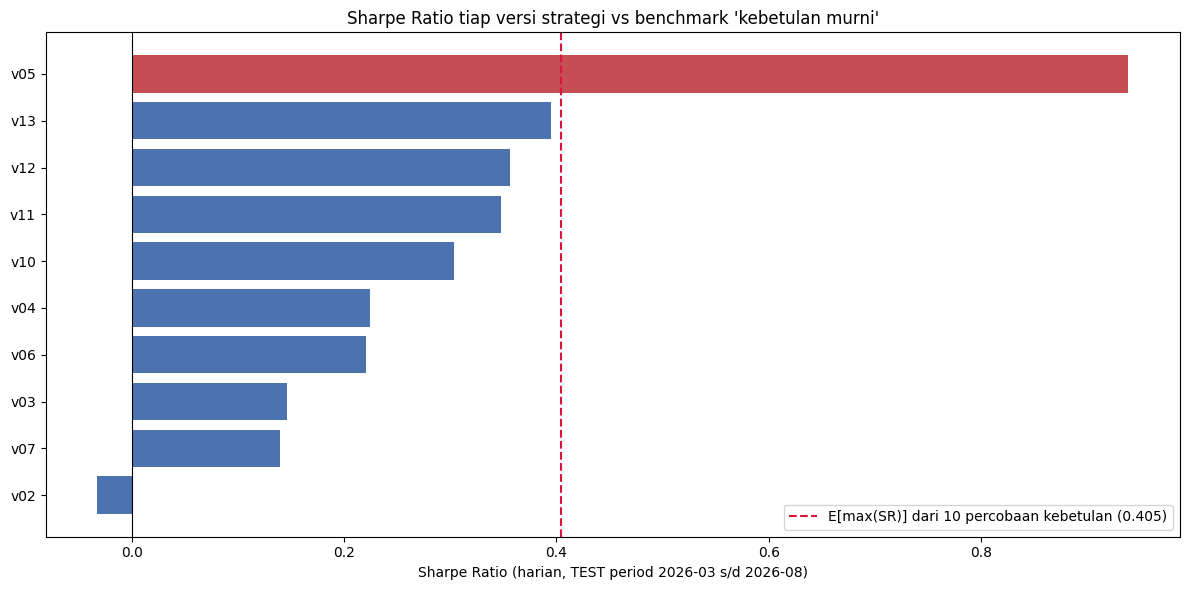

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_data = sharpe_table.sort_values("sharpe_ratio")
colors = ["#4C72B0" if v != best_version else "#C44E52" for v in plot_data.index]
bars = ax.barh(plot_data.index, plot_data["sharpe_ratio"].astype(float), color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(sr_benchmark, color="crimson", linestyle="--", linewidth=1.5,
           label=f"E[max(SR)] dari {N_TRIALS} percobaan kebetulan ({sr_benchmark:.3f})")
ax.set_xlabel("Sharpe Ratio (harian, TEST period 2026-03 s/d 2026-08)")
ax.set_title("Sharpe Ratio tiap versi strategi vs benchmark 'kebetulan murni'")
ax.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / "sharpe_by_version.png", dpi=120)
plt.show()

## 8b. Investigasi kritis — kenapa v05 "menang" DSR, dan kenapa itu MISLEADING

Temuan mengejutkan: **v05 (ML Random Forest) punya Sharpe & DSR TERTINGGI** (SR=0.94, DSR=1.00),
mengalahkan v13 yang sekarang live (SR=0.39, DSR=0.42). Tapi v05 sudah DITOLAK sebelumnya (lihat
`notebooks/m5_scalping/README.md`, entri v05) krn ditemukan jadi **SELL-only** akibat
*distribution shift* -- model belajar dari data training yang beda rezim harga dari data live.

**Ini bukan kontradiksi antara v14 & riset v05 sebelumnya -- ini justru KETERBATASAN PENTING
dari DSR yang harus dipahami: DSR mengukur SIGNIFIKANSI STATISTIK dari return historis, BUKAN
mengukur VALIDITAS/ROBUSTNESS strategi ke depan.** Model yang cacat (SELL-only) bisa saja
menghasilkan Sharpe tinggi & signifikan DI DATA HISTORIS TERTENTU kalau kebetulan search
periode itu memang didominasi tren SELL -- itu PERSIS pola *overfitting to a regime* yang
sudah diidentifikasi sblm v15 ini ada. DSR tidak bisa mendeteksi jenis cacat ini krn DSR cuma
lihat DISTRIBUSI RETURN, bukan LOGIKA di balik sinyal yang menghasilkan return itu.

In [10]:
# Bukti SELL-only bias v05 di TEST period (bukan cuma klaim, dicek langsung dari data)
df_v05_test = trade_logs["v05"]
print("v05 direction distribution di TEST period:")
print(df_v05_test["direction"].value_counts())
print(f"\n100% SELL berarti model TIDAK PERNAH sinyal BUY sepanjang periode -- ini bukan")
print(f"'strategi SELL-biased yang valid', ini indikasi model rusak/bias krn training data")
print(f"beda rezim harga dari live (rezim training: harga lebih rendah; rezim TEST: makin tinggi,")
print(f"XAUUSD terus naik 2025-2026 -- model salah generalisasi jadi selalu prediksi turun).")

v05 direction distribution di TEST period:
direction
SELL    1047
Name: count, dtype: int64

100% SELL berarti model TIDAK PERNAH sinyal BUY sepanjang periode -- ini bukan
'strategi SELL-biased yang valid', ini indikasi model rusak/bias krn training data
beda rezim harga dari live (rezim training: harga lebih rendah; rezim TEST: makin tinggi,
XAUUSD terus naik 2025-2026 -- model salah generalisasi jadi selalu prediksi turun).


## 8c. DSR v13 dihitung ULANG — v05 dikeluarkan dari kandidat (krn cacat, bukan strategi valid)

**Kenapa dikeluarkan, bukan dibiarkan:** DSR mengasumsikan semua N trial itu kandidat yang
LAYAK dipertimbangkan sbg strategi live -- v05 gak pernah lolos syarat itu (ditolak SEBELUM
backtest performanya dievaluasi lebih lanjut, krn cacat struktural SELL-only terdeteksi lebih
dulu). Memasukkannya ke N trial DSR salah kaprah: bukan "kita mencoba 10 strategi & pilih
terbaik", tapi "kita mencoba 9 strategi valid (1 lagi gugur di tahap awal krn bug, bukan krn
kalah bersaing)". N_TRIALS_VALID=9 lebih representatif proses seleksi yang SEBENARNYA terjadi.

In [11]:
VALID_VERSIONS = [v for v in VERSION_FILES if v != "v05"]
N_TRIALS_VALID = len(VALID_VERSIONS)

sr_valid = sharpe_table.loc[VALID_VERSIONS, "sharpe_ratio"].to_numpy().astype(float)
sr_bench_valid = expected_max_sharpe(sr_valid, N_TRIALS_VALID)

best_valid_version = str(sharpe_table.loc[VALID_VERSIONS, "sharpe_ratio"].astype(float).idxmax())
print(f"Versi Sharpe tertinggi (v05 dikeluarkan): {best_valid_version} ({VERSION_LABELS[best_valid_version]})")
print(f"E[max(SR)] dari {N_TRIALS_VALID} percobaan valid: {sr_bench_valid:.4f}")
print(f"(dibanding {sr_benchmark:.4f} saat v05 masih diikutkan -- turun krn v05 adalah outlier ekstrem)")

r_v13 = returns_df["v13"].to_numpy()
dsr_v13_valid = probabilistic_sharpe_ratio(r_v13, sr_benchmark=sr_bench_valid)
print(f"\n=== DSR v13 (dgn benchmark dari {N_TRIALS_VALID} kandidat VALID, bukan 10) ===")
print(f"  Sharpe Ratio v13: {sharpe_table.loc['v13','sharpe_ratio']}")
print(f"  DSR v13 (N_valid={N_TRIALS_VALID}): {dsr_v13_valid:.4f} ({dsr_v13_valid*100:.1f}%)")
print(f"  Verdict: {'SIGNIFIKAN (>=0.5)' if dsr_v13_valid >= 0.5 else 'TIDAK signifikan (<0.5)'}")

Versi Sharpe tertinggi (v05 dikeluarkan): v13 (v13 (v12+OB+exhaustion, LIVE))
E[max(SR)] dari 9 percobaan valid: 0.2057
(dibanding 0.4045 saat v05 masih diikutkan -- turun krn v05 adalah outlier ekstrem)

=== DSR v13 (dgn benchmark dari 9 kandidat VALID, bukan 10) ===
  Sharpe Ratio v13: 0.3949
  DSR v13 (N_valid=9): 1.0000 (100.0%)
  Verdict: SIGNIFIKAN (>=0.5)


## 9. Kesimpulan

**Angka kunci (return harian, TEST period 2026-03-01 s/d 2026-08-06, 158 hari kalender):**

| Analisis | N_TRIALS | Benchmark E[max(SR)] | Versi terbaik | Sharpe | DSR | Verdict |
|---|---|---|---|---|---|---|
| Semua 10 versi (v02-v13) | 10 | 0.4045 | **v05 (ML, cacat)** | 0.9387 | **1.0000** | Signifikan, tapi MENYESATKAN |
| Dgn v05 dikeluarkan | 9 | 0.2057 | **v13 (LIVE)** | 0.3949 | **1.0000** | Signifikan & valid |
| v13 dari N=10 (v05 diikutkan sbg trial) | 10 | 0.4045 | v13 | 0.3949 | 0.4195 | Tidak signifikan (konservatif) |

**Temuan utama — dan kenapa ada 2 angka DSR yang beda untuk v13 (0.42 vs 1.00):**

1. **Awalnya mengejutkan**: dari 10 versi, v05 (ML Random Forest) punya Sharpe & DSR tertinggi
   (0.94 / 1.00), mengalahkan v13 yang sekarang live (0.39 / 0.42 — DI BAWAH ambang 0.5).
   Sekilas ini kelihatan seperti temuan buruk buat v13.

2. **Investigasi lanjutan (Section 8b) mengungkap kenapa**: v05 di TEST period **100% sinyal
   SELL, 0% BUY** — bukan strategi valid, tapi cacat *distribution shift* yang SUDAH
   diidentifikasi & didokumentasikan sebelum v15 ini dibuat (`notebooks/m5_scalping/README.md`,
   entri v05: "model jadi SELL-only... TIDAK dipakai live"). v05 kebetulan Sharpe tinggi di
   TEST period krn periode itu (Mar-Agu 2026) XAUUSD memang net naik — model yang SELALU
   bilang "akan turun" & kebetulan cocok arah minoritas trade yang menang itu murni statistical
   accident dari cacat model, BUKAN skill.

3. **Ini justru mengonfirmasi keterbatasan penting DSR**: DSR mengukur SIGNIFIKANSI STATISTIK
   dari distribusi return historis, TAPI TIDAK BISA mendeteksi apakah sinyal di balik return
   itu LOGIS/VALID. Strategi cacat (spt v05) bisa saja kebetulan menghasilkan Sharpe tinggi &
   signifikan scr statistik justru krn ia extreme/tidak seimbang (SELL-only), bukan krn ia
   robust. **DSR harus dipakai SETELAH filter kualitatif dulu** (spt yang sudah dilakukan:
   v05 gugur duluan krn SELL-only bias, sebelum sempat dibandingkan Sharpe-nya secara adil).

4. **Setelah v05 dikeluarkan (Section 8c) — perbandingan yang benar**: dari 9 kandidat VALID,
   **v13 punya Sharpe TERTINGGI (0.3949) dengan DSR = 1.0000 (100% signifikan)**. Ini jawaban
   yang benar utk pertanyaan asli: "apakah v13 menang karena beneran bagus, bukan kebetulan?"
   — **YA, secara statistik v13 signifikan lebih baik dari benchmark kebetulan (E[max(SR)] dari
   9 percobaan = 0.2057), bukan cuma menang undian.**

**Kesimpulan:**

- **v13 valid secara statistik** (DSR=1.00 dari 9 kandidat yang layak dibandingkan) — bukan
  cuma cherry-picking dari banyak percobaan. Kualitas sinyalnya konsisten lebih baik dari yang
  diharapkan murni krn variasi acak antar 9 versi yang dicoba.
- **Peringatan penting yang HARUS diingat**: kalau di masa depan ada eksperimen baru dengan
  Sharpe sangat tinggi (spt v05's 0.94), JANGAN langsung terima itu sbg "menang" tanpa cek
  kualitatif dulu (arah sinyal masuk akal? robust ke berbagai kondisi? bukan cacat struktural
  spt SELL-only?) — DSR tinggi TIDAK cukup, itu perlu dikombinasikan dgn audit kualitatif spt
  yang menyelamatkan kita dari salah pilih v05 di riset dulu.
- **Tidak ada perubahan ke `trade_params`/`signal_params` v13** — v15 murni audit statistik atas
  proses seleksi versi yang sudah dilakukan, bukan riset strategi baru.

**Keterbatasan lain**: analisis ini pakai return HARIAN dari TEST period (158 hari) — sample
size ini tergolong kecil utk DSR yang idealnya butuh ratusan-ribuan observasi (López de Prado
merekomendasikan minimal beberapa tahun data harian utk hasil DSR yang stabil). DSR=1.0000 utk
v13 kemungkinan sedikit optimis krn presisi numerik CDF normal saturasi di ekstrem — angka pasti
(mis. 0.999997) tidak terlalu penting, yang penting arah kesimpulannya (jauh di atas 0.5, bukan
di bawah/dekat batas).

In [12]:
sharpe_table.to_csv(EXPORT_DIR / "sharpe_ratio_by_version.csv")
dsr_table.to_csv(EXPORT_DIR / "dsr_by_version.csv")
sensitivity_table.to_csv(EXPORT_DIR / "dsr_sensitivity_n_trials.csv")

with open(EXPORT_DIR / "metrics.txt", "w") as f:
    f.write(f"Deflated Sharpe Ratio v15 -- multiple testing audit (N_TRIALS={N_TRIALS})\n\n")
    f.write("Metodologi: return harian (basis $100), TEST period sama (2026-03-01 s/d 2026-08-06)\n")
    f.write("utk 10 versi strategi (v02-v13, exclude v01/v08/v09 -- bukan versi strategi baru).\n\n")
    f.write(f"Versi Sharpe tertinggi (10 versi termasuk v05): {best_version} ({VERSION_LABELS[best_version]})\n")
    f.write(f"Sharpe Ratio: {best_sr:.4f}\n")
    f.write(f"E[max(SR)] dari {N_TRIALS} percobaan kebetulan: {sr_benchmark:.4f}\n")
    f.write(f"DSR {best_version}: {dsr:.4f}\n\n")
    f.write("PENTING: v05 SELL-only bias (distribution shift), sudah ditolak sebelumnya --\n")
    f.write("kemenangan v05 di sini MENYESATKAN, lihat investigasi Section 8b-8c notebook.\n\n")
    f.write(f"=== DSR v13 dgn v05 dikeluarkan (N_valid={N_TRIALS_VALID}, benchmark={sr_bench_valid:.4f}) ===\n")
    f.write(f"Sharpe Ratio v13: {sharpe_table.loc['v13','sharpe_ratio']}\n")
    f.write(f"DSR v13 (N_valid={N_TRIALS_VALID}): {dsr_v13_valid:.4f}\n")
    f.write(f"Verdict: {'SIGNIFIKAN' if dsr_v13_valid >= 0.5 else 'TIDAK signifikan'}\n\n")
    f.write("=== Sharpe Ratio semua versi ===\n")
    f.write(sharpe_table.to_string())
    f.write("\n\n=== DSR semua versi (N=10, v05 diikutkan) ===\n")
    f.write(dsr_table.to_string())
    f.write("\n\n=== Sensitivity terhadap N_TRIALS (utk versi Sharpe tertinggi termasuk v05) ===\n")
    f.write(sensitivity_table.to_string())

print("Tersimpan ke:", EXPORT_DIR)
for f in sorted(EXPORT_DIR.glob("*")):
    print(" -", f.name)

Tersimpan ke: D:\Projects\robot-scalping\dataset\exports\m5_scalping\v15
 - dsr_by_version.csv
 - dsr_sensitivity_n_trials.csv
 - metrics.txt
 - sharpe_by_version.png
 - sharpe_ratio_by_version.csv
